## 📦 Imports

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, ConcatDataset, random_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

## 📁 Demo Data Upload

For this demo, 20kHz current data was collected for 3 minutes from a PMSM with 0g, 50g, and 100g eccentric weights.

In [10]:
# Running motor with no-load, 50g weight, and 100g weight
normal_csv_path = 'multi_class_data/normal.csv'
caution_csv_path = 'multi_class_data/caution.csv'
fault_csv_path  = 'multi_class_data/fault.csv'

# Read CSV files with no header
df_normal = pd.read_csv(normal_csv_path, header=None)
df_caution = pd.read_csv(caution_csv_path, header=None)
df_fault  = pd.read_csv(fault_csv_path, header=None)

print("Normal data shape:", df_normal.shape)
print("Caution data shape:", df_caution.shape)
print("Fault data shape:", df_fault.shape)

Normal data shape: (3593402, 2)
Caution data shape: (3608655, 2)
Fault data shape: (3598514, 2)


## 🔎 Signal Visualization

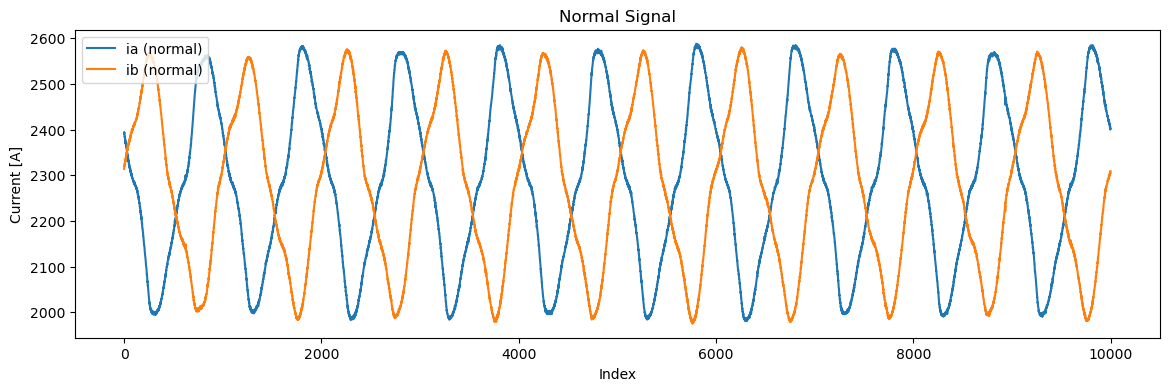

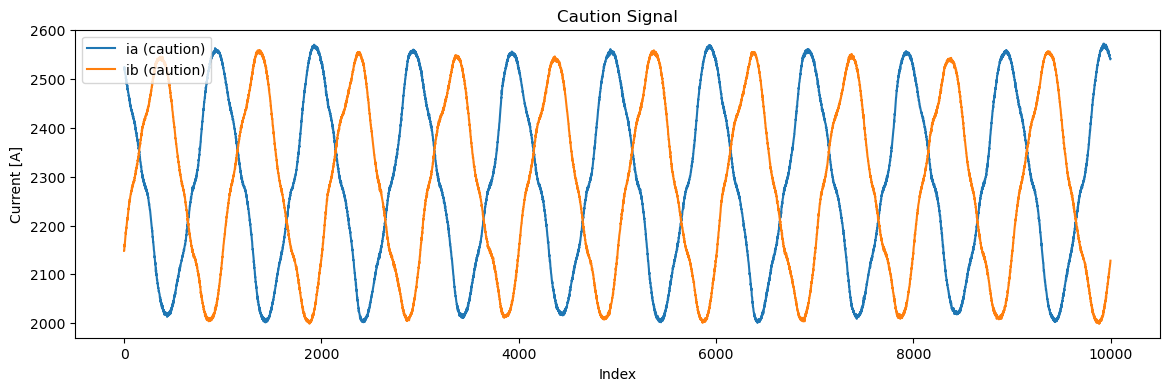

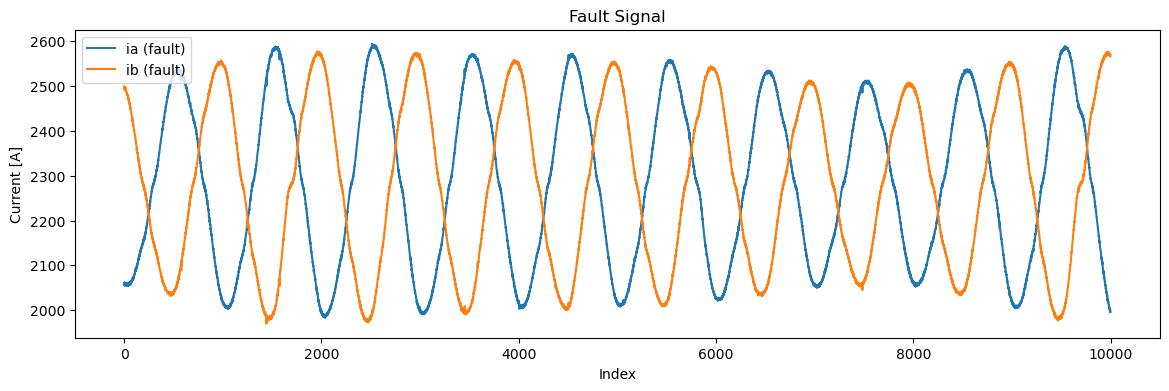

In [38]:
start_idx = int(0.5*1e6)
end_idx = int(0.51*1e6)

plt.figure(figsize=(14, 4))
plt.plot(df_normal[0].iloc[start_idx:end_idx].reset_index(drop=True), label='ia (normal)')
plt.plot(df_normal[1].iloc[start_idx:end_idx].reset_index(drop=True), label='ib (normal)')
plt.title('Normal Signal')
plt.xlabel('Index')
plt.ylabel('Current [A]')
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(df_caution[0].iloc[start_idx:end_idx].reset_index(drop=True), label='ia (caution)')
plt.plot(df_caution[1].iloc[start_idx:end_idx].reset_index(drop=True), label='ib (caution)')
plt.title('Caution Signal')
plt.xlabel('Index')
plt.ylabel('Current [A]')
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(df_fault[0].iloc[start_idx:end_idx].reset_index(drop=True), label='ia (fault)')
plt.plot(df_fault[1].iloc[start_idx:end_idx].reset_index(drop=True), label='ib (fault)')
plt.title('Fault Signal')
plt.xlabel('Index')
plt.ylabel('Current [A]')
plt.legend()
plt.show()

In [ ]:
start_idx = int(0.5*1e6)
end_idx   = int(3.5*1e6)  # Use None for full endz
normal_usable = df_normal.iloc[start_idx:end_idx].reset_index(drop=True)
caution_usable = df_caution.iloc[start_idx:end_idx].reset_index(drop=True)
fault_usable  = df_fault.iloc[start_idx:end_idx].reset_index(drop=True)

print("Usable normal shape:", normal_usable.shape)
print("Usable caution shape:", caution_usable.shape)
print("Usable fault shape:", fault_usable.shape)

Usable normal shape: (3000000, 2)
Usable caution shape: (3000000, 2)
Usable fault shape: (3000000, 2)


## 🗂️ MiniSeqDataset Construction

Builds sequence datasets from raw CSV arrays using sliding windows and assigns labels for each class. Sequence samples from raw data on-the-fly, without caching.

In [ ]:
class MiniSeqDataset(Dataset):
    def __init__(self, arr, label, win_size=2560, step=1280, seq_len=8, per_sample_norm=True):
        # arr: numpy array of shape [N, 2] (no header)
        self.per_sample_norm = per_sample_norm
        self.win_size = win_size
        self.seq_len = seq_len
        self.samples = []
        # Sliding windows
        wins = [arr[s:s+win_size].T  # shape: [2, win_size]
                for s in range(0, len(arr) - win_size + 1, step)]
        for i in range(0, len(wins) - seq_len + 1):
            seq = np.stack(wins[i:i+seq_len])    # [seq_len, 2, win_size]
            self.samples.append((seq, label))
        
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        x, y = self.samples[idx]
        x = torch.tensor(x, dtype=torch.float32)
        if self.per_sample_norm:
            mean = x.mean(dim=(0,2), keepdim=True)
            std  = x.std (dim=(0,2), keepdim=True) + 1e-6
            x = (x - mean) / std
        return x, torch.tensor(y, dtype=torch.long)


## 📤 DataLoader Preparation

Uses a window size 10 times larger for demo as frequency of the data increases.

In [14]:
win_size = 2560   # 10x
step     = 1280   # 10x
seq_len  = 8

normal_ds = MiniSeqDataset(normal_usable, label=0, win_size=win_size, step=step, seq_len=seq_len)
caution_ds = MiniSeqDataset(caution_usable, label=1, win_size=win_size, step=step, seq_len=seq_len)
fault_ds  = MiniSeqDataset(fault_usable,  label=2, win_size=win_size, step=step, seq_len=seq_len)

# Combine datasets & split train/val
full_ds = ConcatDataset([normal_ds, caution_ds, fault_ds])
total_len = len(full_ds)
train_len = int(0.8 * total_len)
val_len = total_len - train_len
train_ds, val_ds = random_split(full_ds, [train_len, val_len])

batch = 32
train_ld = DataLoader(train_ds, batch_size=batch, shuffle=True)
val_ld   = DataLoader(val_ds,   batch_size=batch, shuffle=False)

## 🧠 CNN-LSTM Model Definition

Equal to general trained model. 

In [15]:
class CNN_LSTM(nn.Module):
    def __init__(self, cnn_out=32, lstm_hidden=64, num_classes=3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(2,16,7,padding=3), nn.BatchNorm1d(16), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16,32,5,padding=2), nn.BatchNorm1d(32), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.AdaptiveAvgPool1d(1))
        self.lstm = nn.LSTM(cnn_out, lstm_hidden, 2,
                            batch_first=True, dropout=0.3)
        self.fc = nn.Sequential(
            nn.Linear(lstm_hidden,64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, num_classes))

    def forward(self, x):
        b,s,c,w = x.size()
        feat = self.cnn(x.view(b*s,c,w)).squeeze(-1)     # (b*s, 32)
        lstm_out,_ = self.lstm(feat.view(b,s,-1))
        return self.fc(lstm_out[:,-1])

## 🦾 Model Training Loop

Uses early stopping to halt training if the validation loss does not improve, and saves the best model.

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN_LSTM(num_classes=3).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 7
early_stop_patience = 3

best_val_loss = float('inf')
early_stop_counter = 0
train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(num_epochs):
    # Train
    model.train()
    train_loss, train_corr, train_total = 0, 0, 0
    for X_batch, y_batch in train_ld:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
        preds = outputs.argmax(1)
        train_corr += (preds == y_batch).sum().item()
        train_total += y_batch.size(0)
    train_loss /= train_total
    train_acc = train_corr / train_total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    print(X_batch.shape)
    
    # Validation
    model.eval()
    val_loss, val_corr, val_total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_ld:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
            preds = outputs.argmax(1)
            val_corr += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)
    val_loss /= val_total
    val_acc = val_corr / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f"Epoch {epoch+1}: Train loss={train_loss:.4f} acc={train_acc:.4f} | Val loss={val_loss:.4f} acc={val_acc:.4f}")
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0
        torch.save(model.state_dict(), "best_cnn_lstm.pth")
    else:
        early_stop_counter += 1
        if early_stop_counter >= early_stop_patience:
            print("Early stopping triggered.")
            break

torch.Size([4, 8, 2, 2560])
Epoch 1: Train loss=0.5591 acc=0.7425 | Val loss=0.0331 acc=1.0000
torch.Size([4, 8, 2, 2560])
Epoch 2: Train loss=0.1600 acc=0.9488 | Val loss=0.0213 acc=1.0000
torch.Size([4, 8, 2, 2560])
Epoch 3: Train loss=0.0567 acc=0.9823 | Val loss=0.8387 acc=0.6924
torch.Size([4, 8, 2, 2560])
Epoch 4: Train loss=0.4454 acc=0.8758 | Val loss=0.0161 acc=1.0000
torch.Size([4, 8, 2, 2560])
Epoch 5: Train loss=0.0667 acc=0.9829 | Val loss=1.3518 acc=0.5667
torch.Size([4, 8, 2, 2560])
Epoch 6: Train loss=0.0797 acc=0.9723 | Val loss=0.0025 acc=1.0000
torch.Size([4, 8, 2, 2560])
Epoch 7: Train loss=0.0428 acc=0.9868 | Val loss=0.0015 acc=1.0000


## ✅ Model Selection & Evaluation

In [17]:
# Load best model
model.load_state_dict(torch.load("best_cnn_lstm.pth"))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for X_batch, y_batch in val_ld:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())
        all_probs.extend(probs.cpu().numpy())
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Metrics
acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
print(f"\nAccuracy:  {acc:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)


C:\Users\awear\AppData\Local\Temp\ipykernel_45392\2611885063.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_cnn_lstm.pth"))



Accuracy:  1.0000
F1-score:  1.0000
Precision: 1.0000
Recall:    1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       457
           1       1.00      1.00      1.00       469
           2       1.00      1.00      1.00       475

    accuracy                           1.00      1401
   macro avg       1.00      1.00      1.00      1401
weighted avg       1.00      1.00      1.00      1401

Confusion Matrix:
 [[457   0   0]
 [  0 469   0]
 [  0   0 475]]


## 📈 Metric Visualization

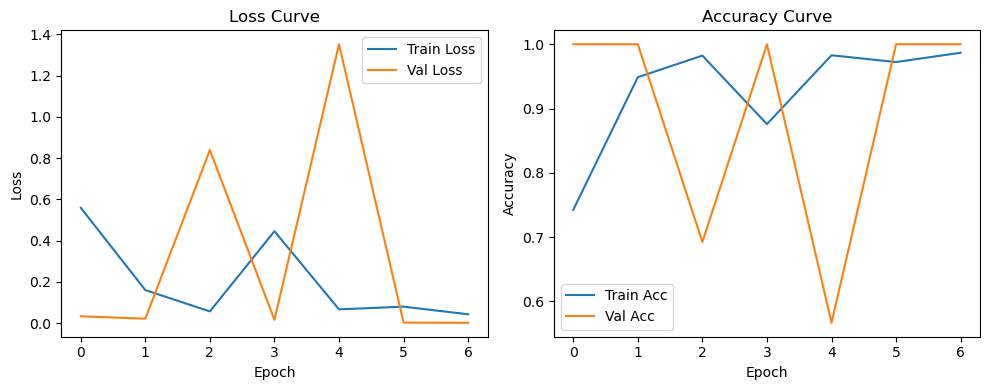

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss Curve')

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Accuracy Curve')
plt.tight_layout()
plt.show()

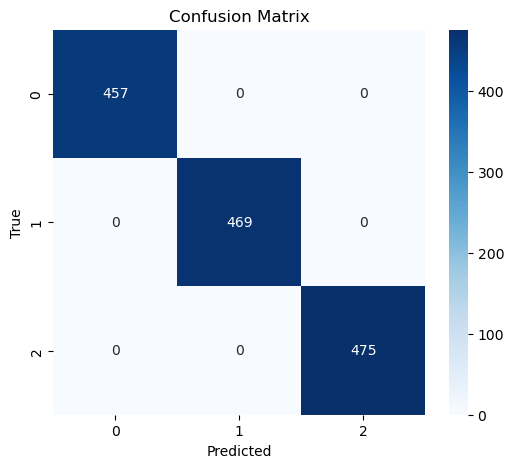

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
plt.show()

## 🧪 New Test File Prediction

A test file containing all three conditions in a single sample is used to evaluate model predictions across different states.

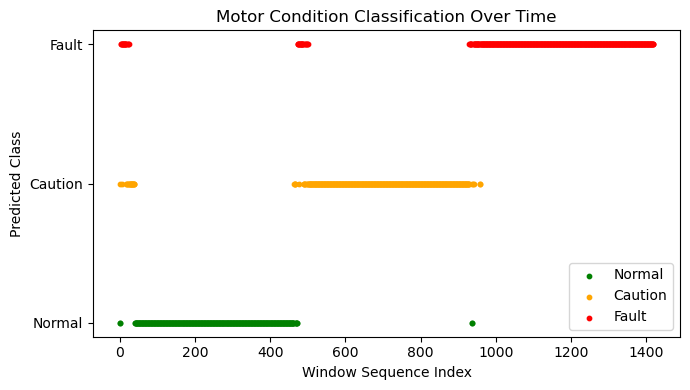

In [ ]:
test_csv_path = "multi_class_data/test.csv"
test_arr = pd.read_csv(test_csv_path, header=None).values

# Sliding window + sequencing (label=0 as dummy)
test_ds = MiniSeqDataset(test_arr, label=0, win_size=win_size, step=step, seq_len=seq_len, per_sample_norm=True)

# DataLoader (batch=32 or 64 for speed)
test_ld = torch.utils.data.DataLoader(test_ds, batch_size=64, shuffle=False)

# Predict all samples
model.eval()
all_preds = []
with torch.no_grad():
    for X_batch, _ in test_ld:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
all_preds = np.array(all_preds) 

# Plot predicted sequence with class names and colors
label_names = {0: 'Normal', 1: 'Caution', 2: 'Fault'}
colors = ['green', 'orange', 'red']
plt.figure(figsize=(7, 4))

# Plot each class with a different color
for label, name in label_names.items():
    idxs = np.where(all_preds == label)[0]
    plt.scatter(idxs, all_preds[idxs], color=colors[label], label=name, s=10)

plt.xlabel('Window Sequence Index')
plt.yticks([0, 1, 2], ['Normal', 'Caution', 'Fault'])
plt.ylabel('Predicted Class')
plt.title('Motor Condition Classification Over Time')
plt.legend()
plt.tight_layout()
plt.show()